In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



/kaggle/input/ae4353-y25/LittletonHQ.h5
/kaggle/input/ae4353-y25/Warsaw1.h5
/kaggle/input/ae4353-y25/autonomous_flight-16a-trackRATM.h5
/kaggle/input/ae4353-y25/sample_submission.csv
/kaggle/input/ae4353-y25/piloted_flight-03p-ellipse.h5
/kaggle/input/ae4353-y25/BaltimoreOB.h5
/kaggle/input/ae4353-y25/autonomous_flight-10a-lemniscate.h5
/kaggle/input/ae4353-y25/piloted_flight-08p-lemniscate.h5
/kaggle/input/ae4353-y25/autonomous_flight-03a-ellipse.h5
/kaggle/input/ae4353-y25/LittletonBlue.h5
/kaggle/input/ae4353-y25/autonomous_flight-15a-trackRATM.h5
/kaggle/input/ae4353-y25/piloted_flight-09p-lemniscate.h5
/kaggle/input/ae4353-y25/piloted_flight-05p-ellipse.h5
/kaggle/input/ae4353-y25/autonomous_flight-17a-trackRATM.h5
/kaggle/input/ae4353-y25/piloted_flight-06p-ellipse.h5
/kaggle/input/ae4353-y25/autonomous_flight-04a-ellipse.h5
/kaggle/input/ae4353-y25/autonomous_flight-14a-trackRATM.h5
/kaggle/input/ae4353-y25/piloted_flight-11p-lemniscate.h5
/kaggle/input/ae4353-y25/test_set.h5
/k

In [2]:
!pip install hdf5plugin opencv-python-headless moviepy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 43.4 MB/s eta 0:00:00


In [3]:
import h5py
import hdf5plugin

import matplotlib.pyplot as plt
from moviepy.editor import ImageSequenceClip

import cv2
from pathlib import Path

import torch
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset
from tqdm import tqdm
import torch.nn.functional as F
from torch import nn


error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evalu

In [4]:
#Lets only train the ones that are the right pixel size.

#maks with multiple zeros, and train on them. But first only one gate.

In [5]:
class NativeResolutionDataset(Dataset):
    """
    An efficient and simple Dataset that loads all data from a single H5 file.
    It assumes the model will train on the original image resolution.
    
    It performs two key steps:
    1. Filters for samples that contain EXACTLY ONE gate.
    2. Extracts and returns only the 8 (x, y) coordinates from the 12-value target.
    """
    def __init__(self, h5_path, transform=None):
        """
        Args:
            h5_path (str): Path to a single H5 file.
            transform (callable, optional): Value-based transforms like normalization.
        """
        self.transform = transform
        
        all_clean_images = []
        all_clean_targets = []

        print(f"Scanning {os.path.basename(h5_path)} and filtering for single-gate samples...")
        
        with h5py.File(h5_path, 'r') as f:
            images_data = f['images'][:]
            self.image_shape = images_data.shape[2:] # Store the native resolution
            
            keys = sorted(f['targets'].keys(), key=int)
            targets_data = [f['targets'][key][:] for key in keys]

            # --- Simplified Filtering and Processing Logic ---
            for idx, target in enumerate(targets_data):
                
                # Check if the target is for a single gate (12 values)
                if target.size == 12:

                    # Extract the visibility flags at indices 2, 5, 8, 11
                    visibility_flags = target[0][[2, 5, 8, 11]]
                    
                    # Check if ALL of these flags are equal to 2
                    if np.all(visibility_flags == 2):
                        all_clean_images.append(images_data[idx])
                        target_coords = target.reshape(4, 3)[:, :2]
                        all_clean_targets.append(target_coords.flatten()) # Flatten to 8 values
  
        
        # --- Store the final, clean data ---
        # All images from this file are the same size, so np.array works
        self.images = np.array(all_clean_images)
        self.targets = np.array(all_clean_targets)

        print(f"Scan Complete! Found {len(self.images)} valid single-gate samples.")
        print(f"Images will be trained at their native resolution: {self.image_shape}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # This is now incredibly simple and fast
        image = self.images[idx]
        target = self.targets[idx]
        
        # The target is already a clean 8-element vector
        target_tensor = torch.from_numpy(target).float()
            
        image_tensor = torch.from_numpy(image).float() / 255.0
        
        # Apply value-based transforms (like normalization)
        if self.transform:
            image_tensor = self.transform(image_tensor)
            
        return image_tensor, target_tensor

In [6]:
# 1. Specify file paths
DATA_ROOT = '/kaggle/input/ae4353-y25' # Corrected path from your code

# Training on all files
#h5_paths = [os.path.join(DATA_ROOT, fname) for fname in os.listdir(DATA_ROOT) if fname.endswith('.h5')]

files_to_use = [
        'autonomous_flight-08a-lemniscate.h5', 'piloted_flight-03p-ellipse.h5', 'piloted_flight-08p-lemniscate.h5',
        'autonomous_flight-01a-ellipse.h5', 'autonomous_flight-13a-trackRATM.h5'
    ]
h5_paths = [os.path.join(DATA_ROOT, fname) for fname in files_to_use]

# 1. Define transforms (NO resizing)
value_transforms = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

list_of_data = [
    NativeResolutionDataset(path, transform=value_transforms) for path in h5_paths
]

full_dataset = ConcatDataset(list_of_data)

# 4. Create your training and validation split
total_len = len(full_dataset)
train_len = int(0.85 * total_len)
val_len = total_len - train_len
train_set, val_set = torch.utils.data.random_split(full_dataset, [train_len, val_len])


# 5. Create train and validation loaders (NO collate_fn needed)
train_loader = DataLoader(
    dataset=train_set,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    dataset=val_set,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

# 6. Test the DataLoader (it will return two items)
print("\nFetching one batch from the DataLoader...")
images_batch, targets_batch = next(iter(train_loader))
print(f"Min value in batch: {images_batch.min()}")
print(f"Max value in batch: {images_batch.max()}")

print("SUCCESS! The batch was loaded with uniform, single-gate targets.")
print(f"Images batch shape:  {images_batch.shape}")
print(f"Targets batch shape: {targets_batch.shape}") # Should be [32, 12]

Scanning autonomous_flight-08a-lemniscate.h5 and filtering for single-gate samples...
Scan Complete! Found 0 valid single-gate samples.
Images will be trained at their native resolution: (480, 640)
Scanning piloted_flight-03p-ellipse.h5 and filtering for single-gate samples...
Scan Complete! Found 124 valid single-gate samples.
Images will be trained at their native resolution: (480, 640)
Scanning piloted_flight-08p-lemniscate.h5 and filtering for single-gate samples...
Scan Complete! Found 229 valid single-gate samples.
Images will be trained at their native resolution: (480, 640)
Scanning autonomous_flight-01a-ellipse.h5 and filtering for single-gate samples...
Scan Complete! Found 29 valid single-gate samples.
Images will be trained at their native resolution: (480, 640)
Scanning autonomous_flight-13a-trackRATM.h5 and filtering for single-gate samples...
Scan Complete! Found 182 valid single-gate samples.
Images will be trained at their native resolution: (480, 640)

Fetching one ba

In [7]:
class VanillaCNN(nn.Module):
    """
    A vanilla convolutional neural network model.
    with the following architecture:
    - Three convolutional layers each with 3x3 kernels, stride=1 w/ ReLU activation followed by a max pooling layer with 2x2 kernels.
    - The first layer has 16 output channels, the second has 32 output channels, and the third has 64 output channels.
    - Flatten the output of the last convolutional layer.
    - Two fully connected layers with ReLU activation with 128 hidden units and 64 hidden units.
    - One fully connected layer with linear activation as the output layer.

    Args:
        channel_in (int): Number of input channels.
        channel_out (int): Number of output channels.
        last_layer_bias (bool, optional): Whether to include bias in the last layer. Defaults to True.

    Attributes:
        conv1 (nn.Conv2d): First convolutional layer.
        conv2 (nn.Conv2d): Second convolutional layer.
        conv3 (nn.Conv2d): Third convolutional layer.
        fc1 (nn.LazyLinear): First fully connected layer.
        fc2 (nn.Linear): Second fully connected layer.
        fc3 (nn.Linear): Third fully connected layer.

    Methods:
        forward(x): Forward pass of the model.

    """
    
    def __init__(self, channel_in, channel_out, last_layer_bias=True):
        super().__init__()

        #--------------------------------------------------------------
        # TODO 2.1: Define the layers of the CNN as described above
        #--------------------------------------------------------------

        self.conv1 = nn.Conv2d(channel_in, 16, kernel_size=3, stride=1)     #stride is hoe die over de pixels heengaan
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=1)
        
        self.fc1 = nn.LazyLinear(out_features=128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, channel_out, bias=last_layer_bias)

        
    def forward(self, x):
        

        x = F.relu(self.conv1(x))       # Use F.relu for space efficent coding
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
    
        return self.fc3(x)
        

In [8]:
def evaluate(val_loader, model, criterion):
    """
    Evaluate the performance of a model on a given dataloader.
    """
    model.eval()
    
    losses = [] # Renamed to 'losses' to be more descriptive
    predictions = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Eval", leave=False):
            images, targets = batch

            images = images.to(device) # Plural 'images' matches batch
            targets = targets.to(device) # Plural 'targets' matches batch
            
            # --- FIX 1: Typo Correction ---
            prediction = model(images)
            
            # --- FIX 2: Correctly calculate the loss item ---
            loss_item = criterion(prediction, targets) # 'targets' matches variable from batch
            
            # --- FIX 3: Correct Syntax for Appending ---
            # You must get the scalar value with .item() BEFORE appending to the list.
            # The .append() method itself returns None.
            losses.append(loss_item.item())
            predictions.append([prediction])

    return losses, predictions

In [9]:
def train_epoch(train_loader, val_loader, model, criterion, optimizer):
    """
    Trains the model for one epoch using the provided data loaders, model, optimizer, and criterion.
    Args:
        train_loader (torch.utils.data.DataLoader): Data loader for the training set.
        val_loader (torch.utils.data.DataLoader): Data loader for the validation set.
        model (torch.nn.Module): The model to be trained.
        optimizer (torch.optim.Optimizer): The optimizer used for training.
        criterion (torch.nn.Module): The loss function used for training.
    Returns:
        tuple: A tuple containing the training loss, training performance, validation performance, and validation predictions.
    """
    # --------------------------------------------------------------
    # TODO 4.1: Implement the training loop for one epoch
    # --------------------------------------------------------------
    
    model.train()

    train_loss = []
    train_pred = []

    for batch in tqdm(train_loader, desc="Batch training", leave=False):
        
            images, targets = batch
        
            # indices_to_keep = [0, 1, 3, 4, 6, 7, 9, 10]
            # targets = targets[:, indices_to_keep]

            images = images.to(device) # Plural 'images' matches batch
            targets = targets.to(device) # Plural 'targets' matches batch

            optimizer.zero_grad()

            prediction = model(images)
    
            loss_item = criterion(prediction, targets)
        
            loss_item.backward()
            
            optimizer.step()

            train_loss.append(loss_item.item())
            train_pred.append([prediction])
    
    val_loss, val_pred = evaluate(val_loader, model, criterion)
    
    # --------------------------------------------------------------
    # END OF TODO 4.1
    # --------------------------------------------------------------

    return train_loss, train_pred, val_loss, val_pred

🚀 Starting training...


Batch training: 100%|██████████| 15/15 [00:05<00:00,  3.75it/s]
                                                               
Eval:  67%|██████▋   | 2/3 [00:00<00:00,  6.16it/s]
                                                   

Epoch 01/3 | Train Loss: 0.852119 | Val Loss: 0.059836


Epochs:  33%|███▎      | 1/3 [00:05<00:11,  5.86s/it]

🏆 New best model found! Saving model state.


...

🏆 New best model found! Saving model state.



Batch training: 100%|██████████| 15/15 [00:04<00:00,  3.70it/s]
                                                               
Eval: 100%|██████████| 3/3 [00:00<00:00,  6.64it/s]
                                                   

Epoch 03/3 | Train Loss: 0.013669 | Val Loss: 0.015972


Epochs: 100%|██████████| 3/3 [00:16<00:00,  5.38s/it]

🏆 New best model found! Saving model state.

✅ Training complete!
Best validation loss achieved: 0.015972


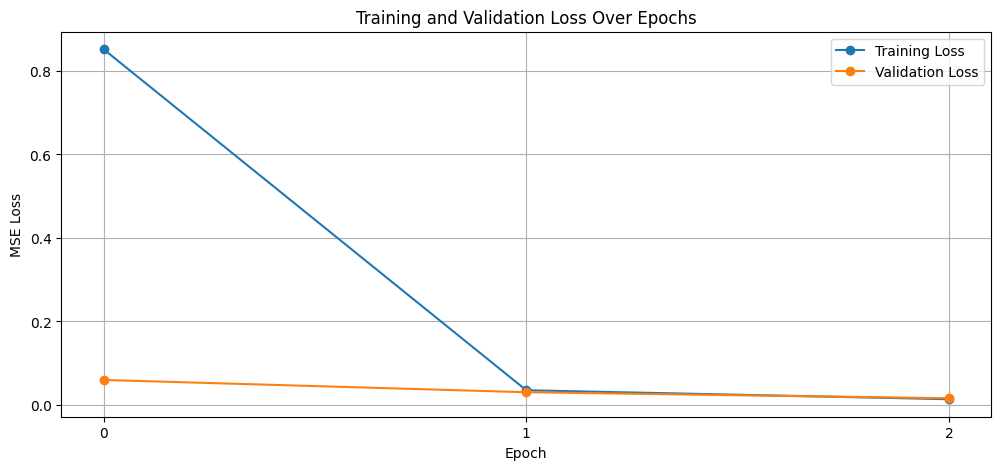

In [10]:
# Define model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

learning_rate = 1e-3
epochs = 3

channel_out = 8
model = VanillaCNN(channel_in=3, channel_out=channel_out).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

# 1. Setup lists to track performance history
history_train_loss = []
history_val_loss = []
best_val_loss = float('inf')

print("🚀 Starting training...")

# 2. Main training loop
for epoch in tqdm(range(epochs), desc='Epochs'):

    # Assuming train_epoch returns: (list_of_batch_train_losses, list_of_batch_train_preds, list_of_batch_val_losses, list_of_batch_val_preds)
    train_loss, train_pred, val_loss, val_pred = train_epoch(train_loader, val_loader, model, criterion, optimizer)
    
    # Calculate the average loss for the entire epoch
    avg_train_loss = np.mean(train_loss)
    avg_val_loss = np.mean(val_loss)
    
    # Store the epoch averages for plotting
    history_train_loss.append(avg_train_loss)
    history_val_loss.append(avg_val_loss)
    
    # Print a summary for the current epoch
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )
    
    # Save the model only if validation loss has improved
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_drone_model.pth')
        print(f"🏆 New best model found! Saving model state.")

print("\n✅ Training complete!")
print(f"Best validation loss achieved: {best_val_loss:.6f}")


# 3. Create the loss curve figure
plt.figure(figsize=(12, 5))
plt.plot(history_train_loss, label='Training Loss', marker='o')
plt.plot(history_val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.xticks(range(0, len(history_train_loss), max(1, len(history_train_loss)//10))) # Clean X-axis ticks
plt.show()
    


Visualizing model performance...


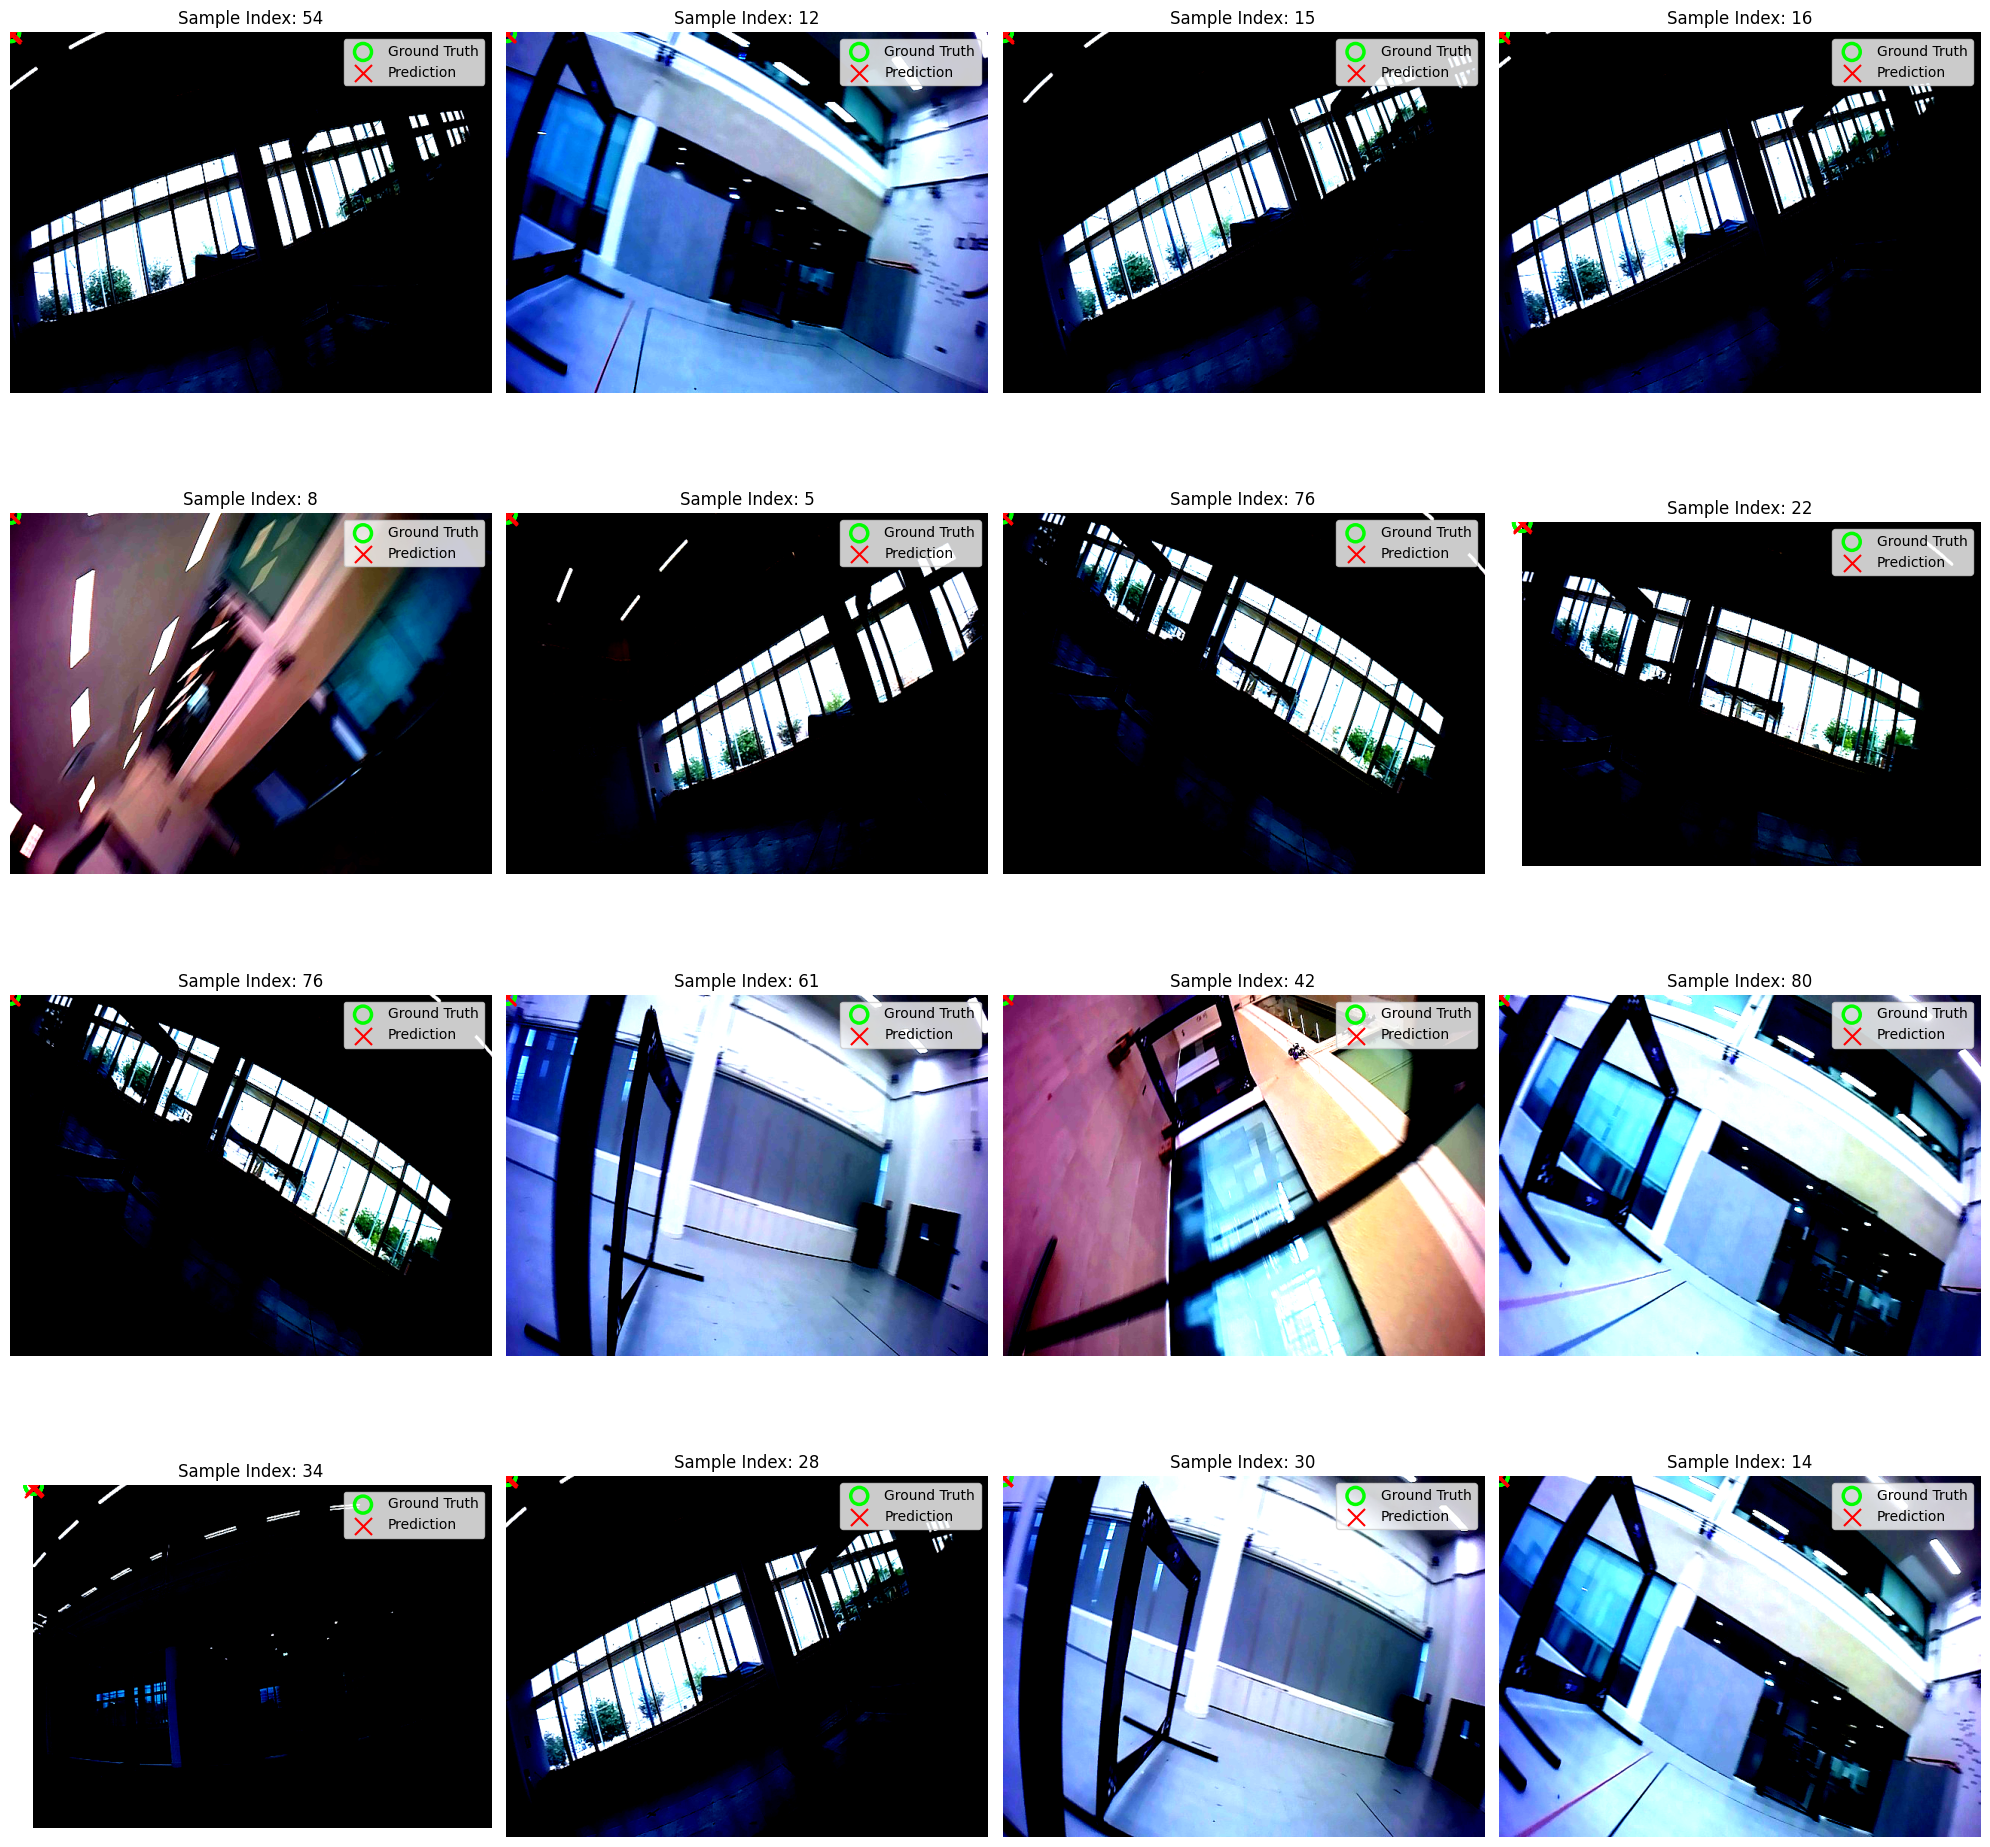

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms # Make sure transforms is imported

def visualize_grid_predictions(model, dataset, data_transforms, device, num_images=16):
    """
    Creates a large grid of predictions, ensuring images are correctly transformed
    before being passed to the model.
    """
    model.eval()
    
    grid_size = int(np.sqrt(num_images))
    if grid_size**2 != num_images:
        raise ValueError("num_images must be a perfect square (e.g., 4, 9, 16).")
        
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20))
    axes = axes.flatten()
        
    for i in range(num_images):
        idx = np.random.randint(0, len(dataset))
        # Get the raw, untransformed image and its 12-value target
        image_tensor, target_12_values = dataset[idx]
        
        # --- THE FIX IS HERE ---
        # Manually apply the same transformations that the training loader uses.
        # This includes resizing and normalizing the image.
        image_transformed = data_transforms(image_tensor)
        
        # Add a batch dimension and send the TRANSFORMED image to the device
        input_image = image_transformed.unsqueeze(0).to(device)
        
        # Get the model's prediction
        with torch.no_grad():
            prediction_8_values = model(input_image)

        # --- The rest of the code is for plotting ---
        prediction_np = prediction_8_values.cpu().numpy()
        target_np = target_12_values.cpu().numpy()
        
        # Un-normalize and prep image for display
        image_to_plot = image_transformed.cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_to_plot = std * image_to_plot + mean
        image_to_plot = np.clip(image_to_plot, 0, 1)

        # Process coordinates for plotting
        target_coords = target_np.reshape(4, 2)
        pred_coords = prediction_np.reshape(4, 2)
        
        # Plotting on the correct subplot
        ax = axes[i]
        ax.imshow(image_to_plot)
        ax.scatter(target_coords[:, 0], target_coords[:, 1], 
                   s=150, facecolors='none', edgecolors='lime', linewidths=2.5, label='Ground Truth')
        ax.scatter(pred_coords[:, 0], pred_coords[:, 1], 
                   s=150, c='red', marker='x', label='Prediction')
        
        ax.set_title(f"Sample Index: {idx}")
        ax.legend()
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# --- HOW TO USE ---

# 1. First, define the exact same transform pipeline used for training

data_transforms = transforms.Compose([
     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ])

# 2. Load your best model
model = VanillaCNN(channel_in=3, channel_out=8).to(device)
model.load_state_dict(torch.load('best_drone_model.pth'))

# 3. Call the visualization function, passing in the transforms
print("\nVisualizing model performance...")
visualize_grid_predictions(model, val_set, data_transforms, device, num_images=16)

In [12]:
!pip install hdf5plugin opencv-python-headless moviepy tqdm 

In [13]:
def h5_to_video(h5, output_dir, fps):
    output_dir.mkdir(parents=True, exist_ok=True)

    # get images and targets
    h5f = h5py.File(h5, "r")
    images = h5f["images"]
    targets = [h5f[f"targets/{i:05d}"][()] for i in range(len(images))]

    # draw targets on images
    frames = []
    for image, target in tqdm(zip(images, targets), total=len(images)):
        image = image.transpose(1, 2, 0)
        frame = image.copy()
        for gate in target:

            
            xy = gate.reshape(-1, 3)[..., :2] * image.shape[1::-1]
            visibility = gate.reshape(-1, 3)[..., 2]
            
            if np.all(visibility > 0):
                cv2.polylines(frame, [xy.astype(int)], isClosed=True, color=(0, 255, 0), thickness=2)
            else:
                # Draw lines between visible corners
                for i in range(len(xy) - 1):
                    if visibility[i] > 0 and visibility[i + 1] > 0:
                        cv2.line(frame, tuple(xy[i].astype(int)), tuple(xy[i + 1].astype(int)), color=(0, 255, 0), thickness=2)
                # Draw line from the last corner to the first to form a loop if both are visible
                if visibility[-1] > 0 and visibility[0] > 0:
                    cv2.line(frame, tuple(xy[-1].astype(int)), tuple(xy[0].astype(int)), color=(0, 255, 0), thickness=2)
        frames.append(frame)

    h5f.close()

    clip = ImageSequenceClip(frames, fps=fps)
    clip.write_videofile(str(output_dir / f"{h5.stem}.mp4"), codec="libx264")

In [14]:
# h5_to_video(Path("/kaggle/input/ae4353-y25/WashingtonOBNewLight.h5"), Path('.'), 30)